# Results Analysis
This notebook performs data analysis on the data in the `results/` folder.

In [86]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from dataclasses import dataclass
import re

Data from each training file stored in the `results/` folder is stored in the TrainingData object, defined by the dataclass below. Some useful functions for data analysis are also stored in this dataclass.

In [131]:
# Define a dataclass to hold the training data and associated metadata
@dataclass
class TrainingData:
    training_samples: list[int]     # Number of training samples seen by the model at each step
    gradients: list[float]          # The gradient values at each training step
    loss_values: list[float]        # The loss values at each training step
    accuracies: list[float]         # This list may have different length than the others, as accuracies are only calculated once per epoch
    qubits: int
    layers: int
    epochs: int
    batch_size: int
    shots: int
    noise_model: str|None = None
    depolarising_noise: float = 0.0                # Default value for depolarising noise
    damping_noise: float = 0.0                     # Default value for amplitude damping noise
    crosstalk_noise: dict[str, float]|None = None  # Default value for crosstalk noise

    def __post_init__(self):
        # Remove leading 0 from training_samples if present
        if self.training_samples and self.training_samples[0] == 0:
            self.training_samples = self.training_samples[1:]
        # Ensure that the training lists have the same length (accuracies only calcaulated once per epoch)
        lengths = [len(self.training_samples), len(self.gradients), len(self.loss_values)]
        if len(set(lengths)) != 1:
            raise ValueError("All lists must have the same length.")
        # Set noise_model to None if it's an empty string or 'none'
        if self.noise_model and self.noise_model.lower() in ("", "none"):
            self.noise_model = None

    def __str__(self):
        return (f"TrainingResults(qubits={self.qubits}, layers={self.layers}, epochs={self.epochs}, "
                f"batch_size={self.batch_size}, shots={self.shots}, noise_model='{self.noise_model}', "
                f"depolarising_noise={self.depolarising_noise}, "
                f"training_samples_length={len(self.training_samples)}, gradients_length={len(self.gradients)}, "
                f"loss_values_length={len(self.loss_values)}, accuracies_length={len(self.accuracies)})")
    
    
    @staticmethod
    def running_average(data, window_size: int):
        """Calculate the running average of the given data."""
        return np.convolve(data, np.ones(window_size)/window_size, mode='valid')
    
    @staticmethod
    def batch_average(data, batch_size: int):
        """Calculate the average of the given data in batches."""
        return [np.mean(data[i:i + batch_size]) for i in range(0, len(data), batch_size)]
    
    @staticmethod
    def parse_noise_model(noise_model: str, parse_params: bool = True) -> str|tuple[str, dict[str, float]]:
        """
        Parses a noise model string to extract a name and its specific noise parameters.

        Assumes the noise model string is formatted like `<number_of_qubits>-qubit-<noise_type>(p_depol=<value>, p_damp=<value>)`. The function extracts the noise type and its associated probability value.
        For example, if the noise model is `'single-qubit-depol(p=0.01)'`, it will return `("Single Qubit Depol", {'depolarising_noise': 0.01})`.
        """
        noise_params = {}

        noise_type = noise_model.split("(")[0]                       # 1. Extract the part before the '('
        noise_type = noise_type.replace("-", " ").replace("_", " ")  # 2. Replace hyphens and underscores with spaces
        noise_type = noise_type.title()                              # 3. Convert to title case
        if not parse_params:
            return noise_type, noise_params

        noise_params_str = noise_model.split('(')[1].rstrip(')')          # 4. Extract the part inside the parentheses
        noise_params_list = noise_params_str.replace(" ", "").split(",")  # 5. Split by commas to get individual parameters

        for param in noise_params_list:
            key, value = param.split("=")
            if key == "p-depol":
                noise_params['depolarising_noise'] = float(value)
            elif key == "p-damp":
                noise_params['damping_noise'] = float(value)
            # Add more parsing logic for other noise types as needed

        return noise_type, noise_params
    
    @staticmethod
    def load_from_pickle(file_path:str) -> 'TrainingData':
        """
        Loads training data into a TrainingData object from a pickle file. 

        Uses the file name to extract metadata such as qubits, layers, epochs, batch size, shots, and noise model.
        Extra parsing of noise model may be done to extract specific noise parameters, such as depolarising noise.
        """
        assert os.path.exists(file_path), f"File {file_path} could not be found."
        assert file_path.endswith('.pkl'), f"File {file_path} is not a pickle file."
        with open(file_path, 'rb') as f:
            data = pickle.load(f)
        file_parts = file_path.split("_")
        qubits      = int(file_parts[file_parts.index("qubits") + 1])
        layers      = int(file_parts[file_parts.index("layers") + 1])
        epochs      = int(file_parts[file_parts.index("epochs") + 1])
        batch_size  = int(file_parts[file_parts.index("batch") + 1])
        shots       = int(file_parts[file_parts.index("shots") + 1])
        noise_model = TrainingData.parse_noise_model(file_parts[file_parts.index("noise") + 1].replace(".pkl", ""), parse_params=False)
        depolarising_noise = noise_model[1].get('depolarising_noise', 0.0)
        damping_noise      = noise_model[1].get('damping_noise', 0.0)
        return TrainingData(
            training_samples = data['training_samples'],
            gradients        = data['gradients'],
            loss_values      = data['loss_values'],
            accuracies       = data['accuracies'],
            qubits           = qubits,
            layers           = layers,
            epochs           = epochs,
            batch_size       = batch_size,
            shots            = shots,
            noise_model      = noise_model[0],
            depolarising_noise = depolarising_noise,
            damping_noise      = damping_noise
        )
    

In [132]:
TrainingData.parse_noise_model("single-qubit-depol(p-depol=0.01)", parse_params=True)

('Single Qubit Depol', {'depolarising_noise': 0.01})

In [133]:
DIRECTORY = "results/"
DIRECTORY_FILE_NAMES = os.listdir(DIRECTORY)
training_files = [file for file in DIRECTORY_FILE_NAMES if file.startswith("training") and not file.endswith("overfitting.pkl")]
print(training_files)

['training_qubits_10_layers_10_epochs_1_batch_1_shots_10000_noise_depol(p=0.000121).pkl', 'training_qubits_10_layers_10_epochs_1_batch_1_shots_10000_noise_depol(p=0.000422).pkl', 'training_qubits_10_layers_10_epochs_1_batch_1_shots_10000_noise_depol(p=0.00147).pkl', 'training_qubits_10_layers_10_epochs_1_batch_1_shots_10000_noise_depol(p=0.00199).pkl', 'training_qubits_10_layers_10_epochs_1_batch_1_shots_10000_noise_depol(p=0.00511).pkl', 'training_qubits_10_layers_10_epochs_1_batch_1_shots_10000_noise_depol(p=1e-05).pkl', 'training_qubits_10_layers_10_epochs_1_batch_1_shots_10000_noise_depol(p=3.48e-05).pkl', 'training_qubits_10_layers_10_epochs_1_batch_1_shots_10000_noise_none.pkl']


In [135]:
training_data_list = []
for file in training_files:
    data = TrainingData.load_from_pickle(os.path.join(DIRECTORY, file))
    training_data_list.append(data)
        
with open("results\\replicarun_8_qubits_1.00e-05_depolarising_noise.pkl", "rb") as file:
    results_6_qubits = pickle.load(file)

In [136]:
training_data_list.sort(key=lambda x: x.depolarising_noise)  # Sort the list by depolarising noise for easier analysis
print(str(training_data_list[0]))

TrainingResults(qubits=10, layers=10, epochs=1, batch_size=1, shots=10000, noise_model='Depol', depolarising_noise=0.0, training_samples_length=15000, gradients_length=15000, loss_values_length=15000, accuracies_length=1)


In [67]:
print(f"Length of training samples: {len(training_data_list[0].training_samples)} \nLength of accuracies: {len(training_data_list[0].accuracies)} \nLength of loss values: {len(training_data_list[0].loss_values)}\nLength of gradients: {len(training_data_list[0].gradients)}")

Length of training samples: 15000 
Length of accuracies: 1 
Length of loss values: 15000
Length of gradients: 15000


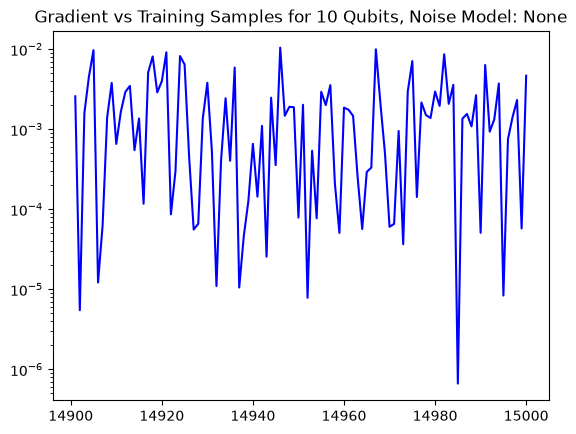

In [68]:
plt.plot(training_data_list[0].training_samples[-100:], training_data_list[0].gradients[-100:], label=f'{training_data_list[0].qubits} Qubits', color='blue')
plt.title(f'Gradient vs Training Samples for {training_data_list[0].qubits} Qubits, Noise Model: {training_data_list[0].noise_model}')
plt.yscale('log')

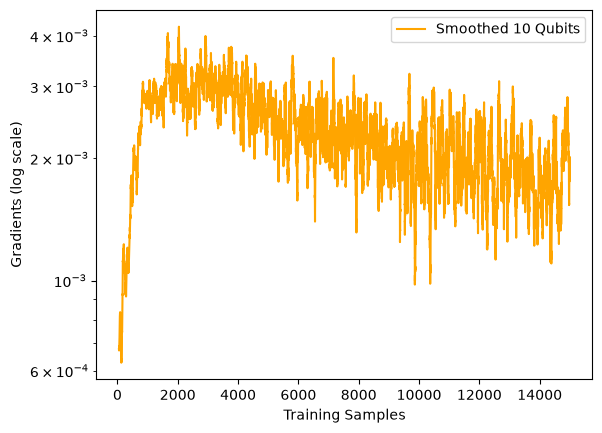

In [69]:
# Use running average to smooth the gradients for better visualization
window_size = 50
smoothed_gradients = TrainingData.running_average(training_data_list[0].gradients, window_size)
smoothed_training_samples = training_data_list[0].training_samples[window_size - 1:]  # Adjust the training samples to match the smoothed gradients

# Plot the smoothed gradients
plt.plot(smoothed_training_samples, smoothed_gradients, label=f'Smoothed {training_data_list[0].qubits} Qubits', color='orange')
plt.xlabel('Training Samples')
plt.ylabel('Gradients (log scale)')
plt.yscale('log')
plt.legend()
plt.show()

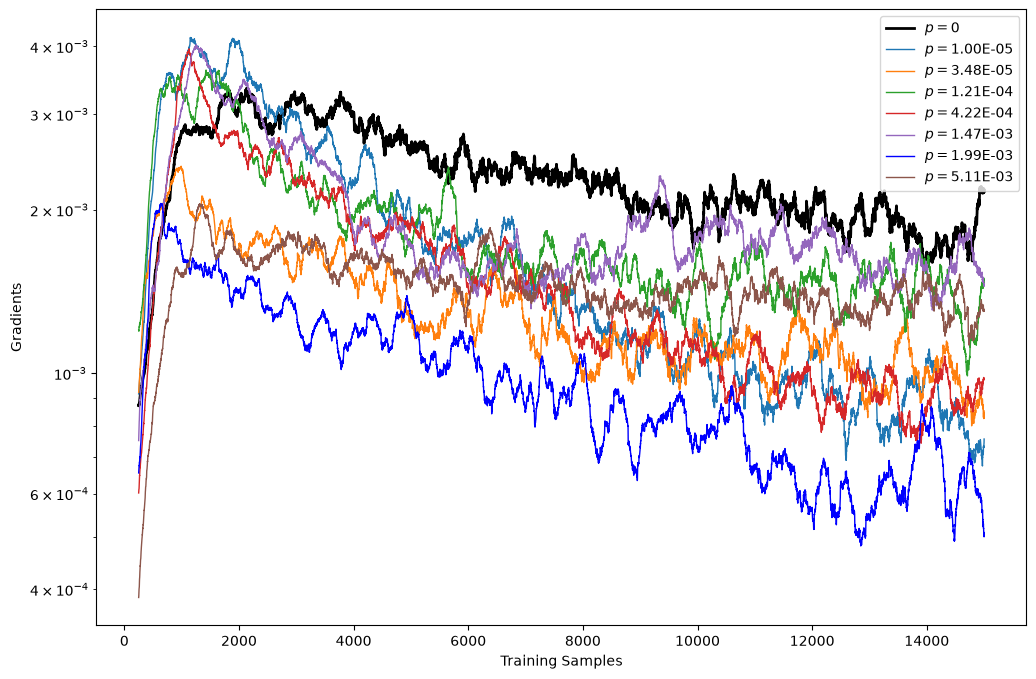

In [70]:
window_size = 250  # Define the window size for running average
colors = sns.color_palette(['black', 'C0', 'C1', 'C2', 'C3', 'C4', 'blue', 'C5'], len(training_data_list))  # Generate a color palette
plt.figure(figsize=(12, 8))
for data in training_data_list:
    smoothed_gradients = TrainingData.running_average(data.gradients, window_size)
    smoothed_training_samples = data.training_samples[window_size - 1:]  # Adjust the training samples to match the smoothed gradients
    label = f'$p=${data.depolarising_noise:.2E}' if data.depolarising_noise > 0 else '$p=0$'
    linewidth = 2 if data.depolarising_noise == 0 else 1  # Thicker line for no depolarising noise
    plt.plot(smoothed_training_samples, smoothed_gradients, label=label, color=colors[training_data_list.index(data)], linewidth=linewidth)

plt.xlabel('Training Samples')
plt.ylabel('Gradients')
plt.yscale('log')
plt.legend()
plt.show()

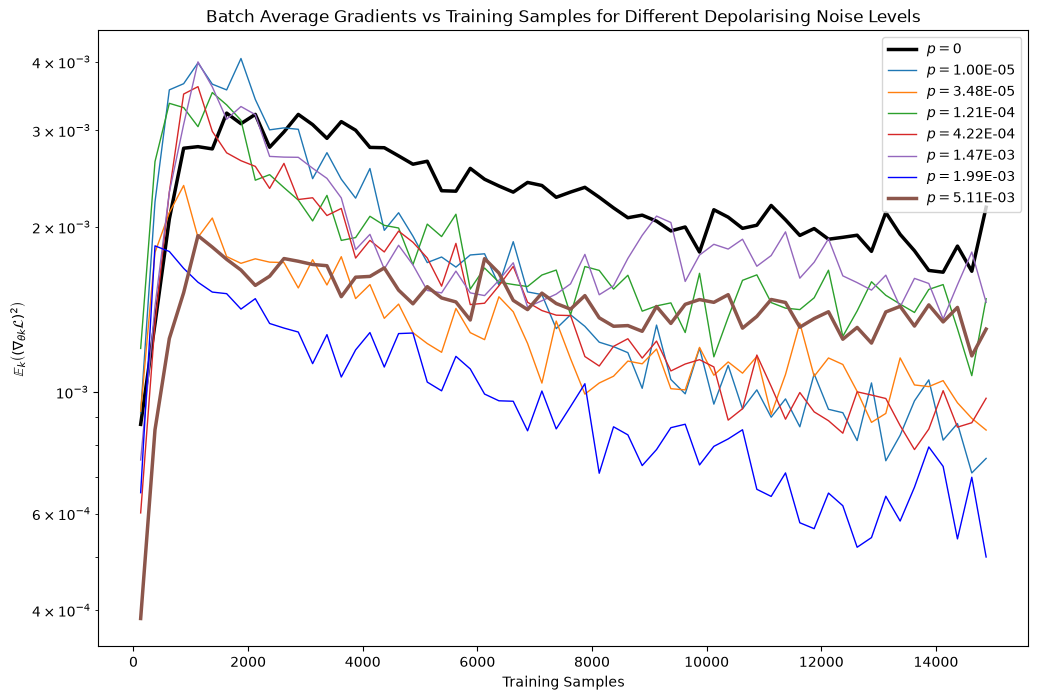

In [71]:
# Create a plot using batch averages instead of running averages
batches_size = 250  # Define the window size for batch average
plt.figure(figsize=(12, 8))
for data in training_data_list:
    batch_avg_gradients        = TrainingData.batch_average(data.gradients, batches_size)
    batch_avg_training_samples = TrainingData.batch_average(data.training_samples, batches_size)

    label = f'$p=${data.depolarising_noise:.2E}' if data.depolarising_noise > 0 else '$p=0$'
    linewidth = 2.5 if (data.depolarising_noise == 0 or data.depolarising_noise > 5e-3) else 1  # Thicker line for no depolarising noise
    plt.plot(batch_avg_training_samples, batch_avg_gradients, label=label, color=colors[training_data_list.index(data)], linewidth=linewidth)
plt.xlabel('Training Samples')
plt.ylabel(r'$\mathbb{E}_k \left( (\nabla_{\theta k} \mathcal{L})^2 \right)$')
plt.yscale('log')
plt.legend()
plt.title('Batch Average Gradients vs Training Samples for Different Depolarising Noise Levels')
plt.show()

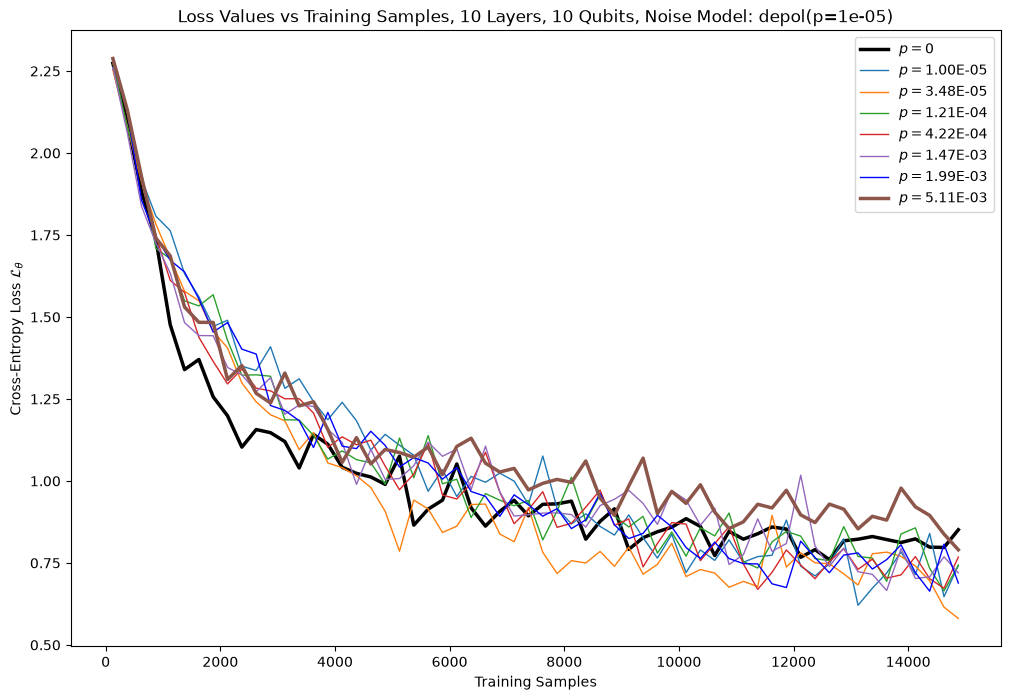

In [79]:
batches_size = 250  # Define the window size for batch average
plt.figure(figsize=(12, 8))
for data in training_data_list:
    batch_avg_loss_values      = TrainingData.batch_average(data.loss_values, batches_size)
    batch_avg_training_samples = TrainingData.batch_average(data.training_samples, batches_size)

    label = f'$p=${data.depolarising_noise:.2E}' if data.depolarising_noise > 0 else '$p=0$'
    linewidth = 2.5 if (data.depolarising_noise == 0 or data.depolarising_noise > 5e-3) else 1
    plt.plot(batch_avg_training_samples, batch_avg_loss_values, label=label, color=colors[training_data_list.index(data)], linewidth=linewidth)
plt.xlabel('Training Samples')
plt.ylabel(r'Cross-Entropy Loss $\mathcal{L}_\theta$')
plt.legend()
plt.title(f'Loss Values vs Training Samples, {training_data_list[0].layers} Layers, {training_data_list[0].qubits} Qubits, Noise Model: {training_data_list[1].noise_model}')
plt.show()